# Extracting Business Cycles from Time Series

# Extracting Business Cycles from Macroeconomic Data

## Introduction

A central challenge in empirical macroeconomics is separating the **trend** component of a time series — its long-run growth path — from the **cyclical** component — the short-run fluctuations around that path. This decomposition is not directly observable: we only see the raw series $y_t$, which is the sum of both components:

$$y_t = \tau_t + c_t$$

where $\tau_t$ is the trend and $c_t$ is the cycle. The cycle is what macroeconomists mean by the "business cycle": the periodic booms and busts that drive fluctuations in unemployment, investment, and living standards. To study business cycles empirically — to measure their amplitude, duration, and comovement across variables and countries — we need a method for extracting $c_t$ from $y_t$.

This notebook develops four widely used methods for doing so, applies each to GDP data from a cross-section of countries, and compares their properties. The methods are:

1. **Log-linear and log-quadratic detrending**: fit a deterministic polynomial trend and treat the residual as the cycle.
2. **Hodrick-Prescott (HP) filter**: choose a smooth time-varying trend by solving a penalized least squares problem.
3. **Hamilton filter**: define the cycle as the unpredictable component of an $h$-step-ahead forecast.
4. **Baxter-King (BK) and Christiano-Fitzgerald (CF) band-pass filters**: isolate fluctuations within the frequency band associated with business cycles.

### Why the Log Transformation?

Most macroeconomic variables exhibit exponential rather than linear growth. If $Y_t$ grows at constant rate $g$ with proportional random deviations:

$$Y_t = (1+g)Y_{t-1} + Y_{t-1}\varepsilon_t$$

then the percentage change is $\Delta Y_t / Y_{t-1} = g + \varepsilon_t$ — a constant plus noise. Taking logarithms, $y_t = \ln Y_t$ transforms the exponential trend into a linear one:

$$y_t \approx y_0 + gt + \text{stationary noise}$$

We should log-transform variables that grow exponentially over time — GDP, consumption, investment, industrial production — but not variables that are already expressed as rates or shares, such as the unemployment rate, the savings rate, or interest rates. All GDP series in this notebook are log-transformed before filtering.

## Data

We download real GDP data for a cross-section of countries from FRED (Federal Reserve Economic Data). We use quarterly, seasonally adjusted real GDP series where available, standardizing each to an index with base year 2015 = 100 to facilitate comparison across countries.

```{note}

Downloaded United States: 176 quarters (1980Q1–2023Q4)
Downloaded United Kingdom: 163 quarters (1980Q1–2020Q3)
Downloaded Germany: 132 quarters (1991Q1–2023Q4)
Downloaded Japan: 120 quarters (1994Q1–2023Q4)
Downloaded Canada: 176 quarters (1980Q1–2023Q4)
Downloaded Australia: 44 quarters (1980Q1–2023Q1)


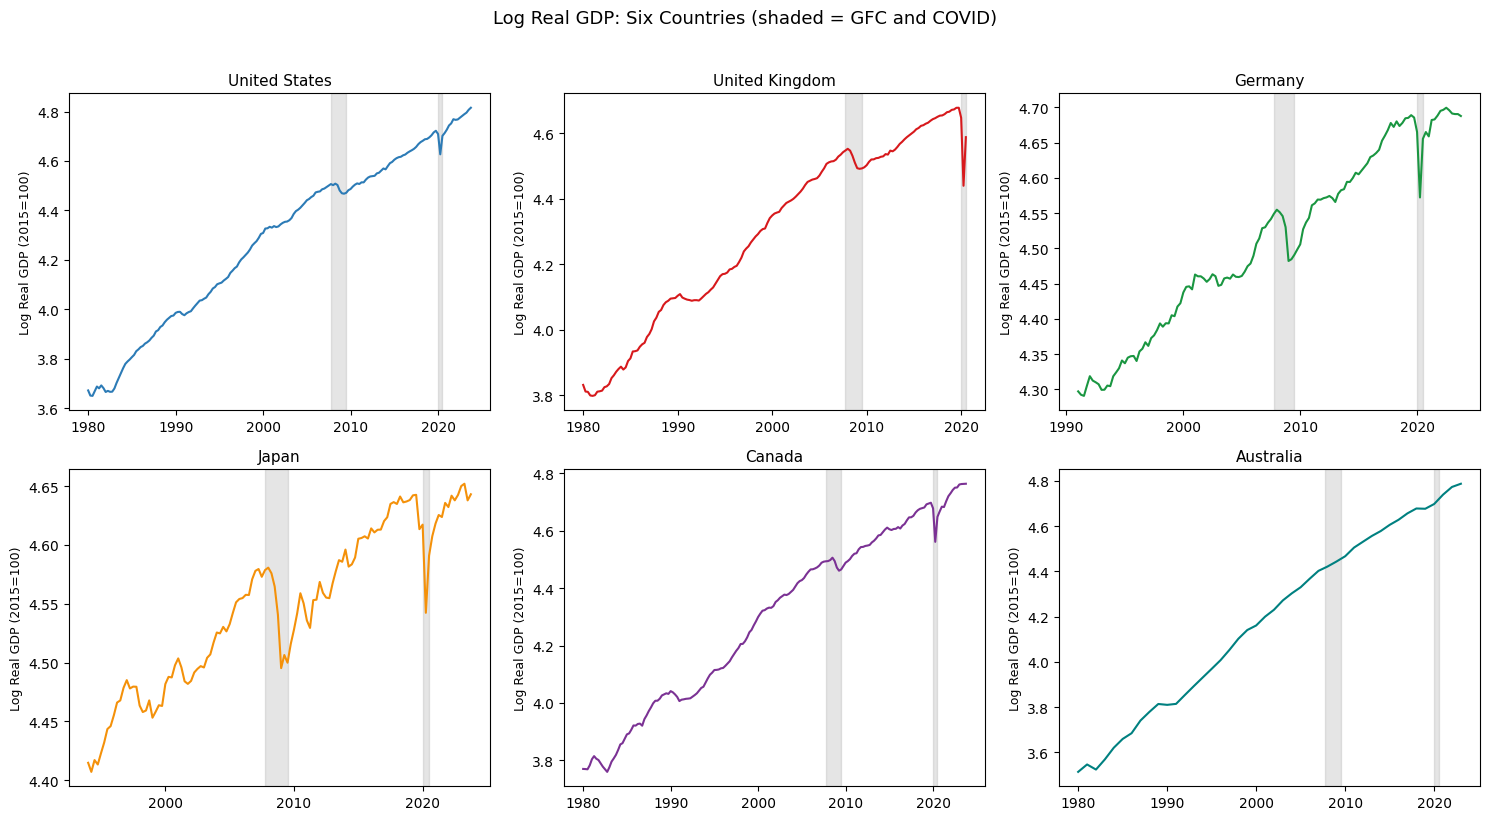

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

# ── Install/import FRED API client ──
try:
    from fredapi import Fred
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "fredapi", "-q"])
    from fredapi import Fred

import statsmodels.api as sm
from scipy.signal import detrend as scipy_detrend
from scipy.stats import pearsonr

# ──────────────────────────────────────────────
# FRED API key
# Replace with your own key or set environment
# variable FRED_API_KEY
# ──────────────────────────────────────────────
import os
FRED_API_KEY = os.environ.get("FRED_API_KEY", "your_fred_api_key_here")
fred = Fred(api_key=FRED_API_KEY)

# ──────────────────────────────────────────────
# Country GDP series on FRED
# All are real GDP, seasonally adjusted
# Units vary by country; we index to 2015Q1=100
# ──────────────────────────────────────────────
gdp_series = {
    "United States" : "GDPC1",        # Billions of Chained 2017 USD
    "United Kingdom": "CLVMNACSCAB1GQUK",   # Millions of Chained 2019 GBP
    "Germany"       : "CLVMNACSCAB1GQDE",   # Millions of Chained 2015 EUR
    "Japan"         : "JPNRGDPEXP",    # Billions of Chained 2015 JPY
    "Canada"        : "NGDPRSAXDCCAQ", # Millions of Chained 2017 CAD
    "Australia"     : "RGDPNAAUA666NRUG",   # Millions of 2015 USD
}

colors = {
    "United States" : "#2c7bb6",
    "United Kingdom": "#d7191c",
    "Germany"       : "#1a9641",
    "Japan"         : "#f4910a",
    "Canada"        : "#7b3294",
    "Australia"     : "#008080",
}

# ──────────────────────────────────────────────
# Download and process
# ──────────────────────────────────────────────
start_date = "1980-01-01"
end_date   = "2023-12-31"

gdp_data = {}
for country, ticker in gdp_series.items():
    try:
        series = fred.get_series(ticker,
                                 observation_start=start_date,
                                 observation_end=end_date)
        series = series.resample("QS").first().dropna()
        # Index to 2015Q1 = 100
        base = series.loc["2015-01-01"] if "2015-01-01" in series.index \
               else series.iloc[len(series)//2]
        series = 100 * series / base
        gdp_data[country] = np.log(series)
        print(f"Downloaded {country}: {len(series)} quarters "
              f"({series.index[0].year}Q{series.index[0].quarter}–"
              f"{series.index[-1].year}Q{series.index[-1].quarter})")
    except Exception as e:
        print(f"Could not download {country}: {e}")

# ──────────────────────────────────────────────
# Plot raw log GDP series
# ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False)
axes = axes.flatten()

for idx, (country, series) in enumerate(gdp_data.items()):
    ax = axes[idx]
    ax.plot(series.index, series.values,
            color=colors[country], lw=1.5)
    # Shade NBER recessions for US; shade 2008Q3-2009Q2 and
    # 2020Q1-2020Q2 for all countries as reference
    for (start, end) in [("2007-10-01", "2009-07-01"),
                          ("2020-01-01", "2020-07-01")]:
        ax.axvspan(pd.to_datetime(start),
                   pd.to_datetime(end),
                   color="gray", alpha=0.2)
    ax.set_title(country, fontsize=11)
    ax.set_ylabel("Log Real GDP (2015=100)", fontsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator(10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("Log Real GDP: Six Countries (shaded = GFC and COVID)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Method 1: Log-Linear and Log-Quadratic Detrending

### Theory

The simplest detrending method fits a deterministic polynomial time trend by OLS and defines the cycle as the residual. For a log-linear trend:

$$y_t = a + gt + \varepsilon_t$$

the trend is $\hat{\tau}_t = \hat{a} + \hat{g}t$ and the cycle is $\hat{c}_t = y_t - \hat{\tau}_t$. A log-quadratic extension adds a squared term to allow for curvature in the trend:

$$y_t = a + g_1 t + g_2 t^2 + \varepsilon_t$$

**When is it appropriate?** Log-linear detrending is appropriate when the data-generating process has a constant growth rate — that is, when the underlying trend is genuinely linear in logs. For most developed economies' GDP, this is a reasonable first approximation over long samples, though it may miss structural breaks in trend growth (such as the productivity slowdown after 1973 or the post-GFC slowdown).

**Limitations.** A deterministic trend assumes that the economy always returns to the same long-run path after a shock — any permanent shift in the level of GDP is attributed to the cycle rather than the trend. If GDP follows a random walk with drift (a stochastic trend), log-linear detrending will produce spuriously persistent cycles.

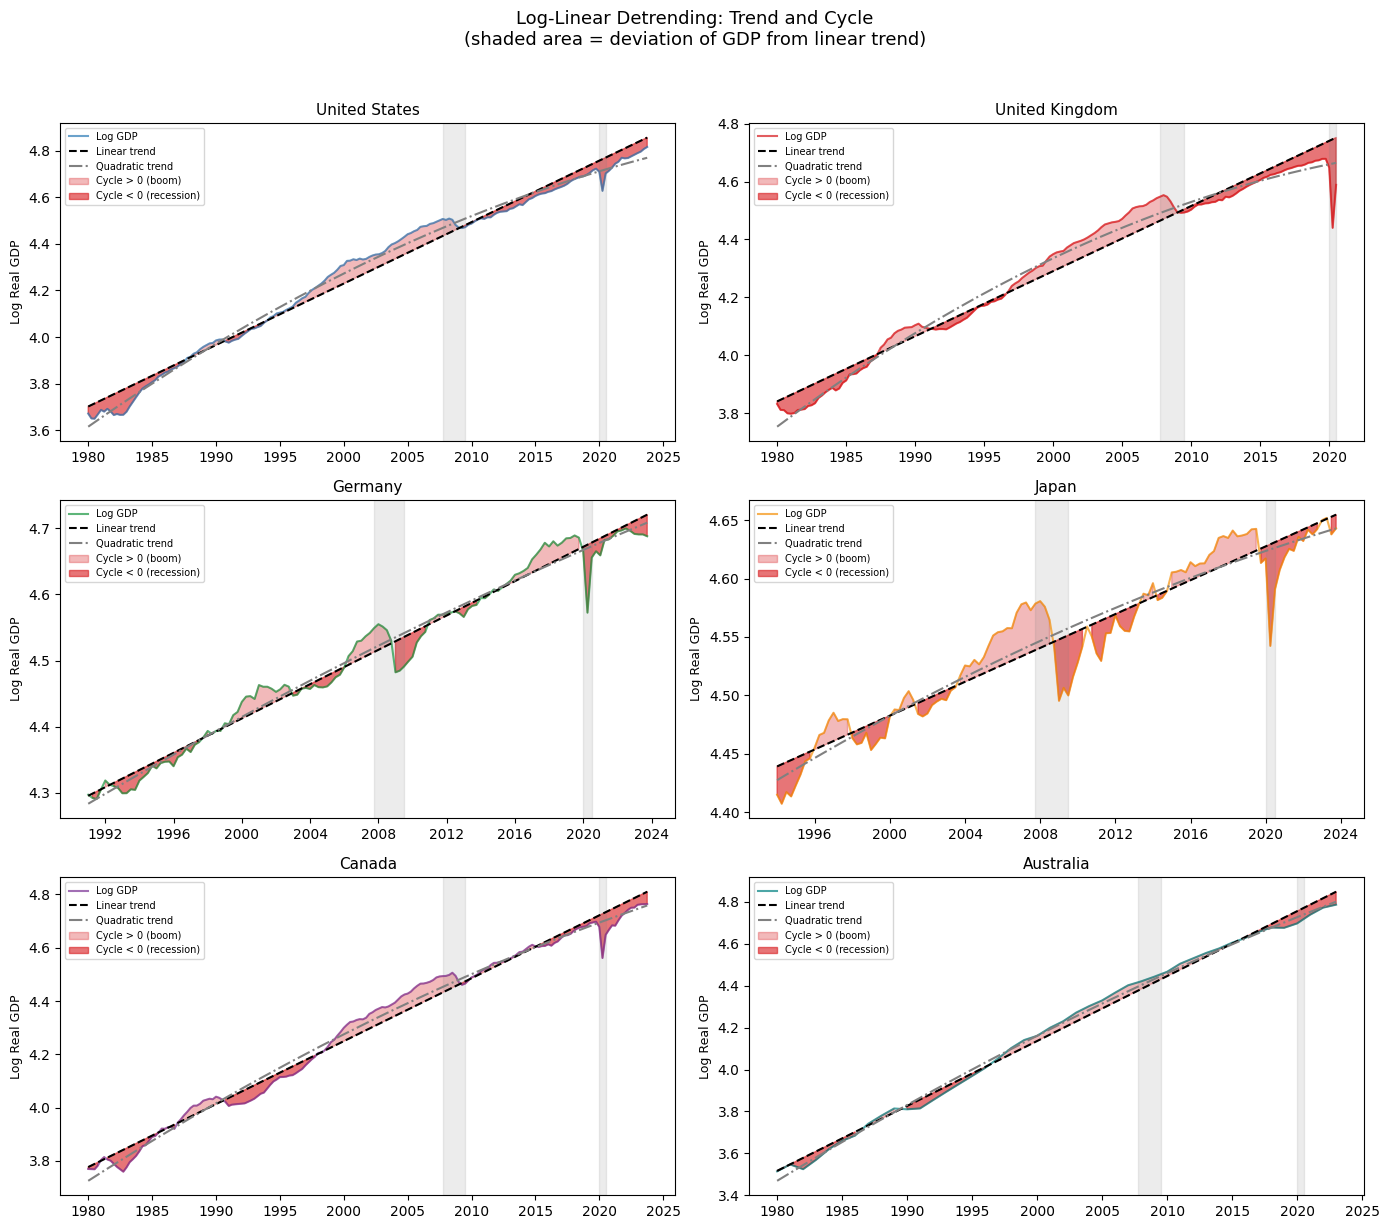

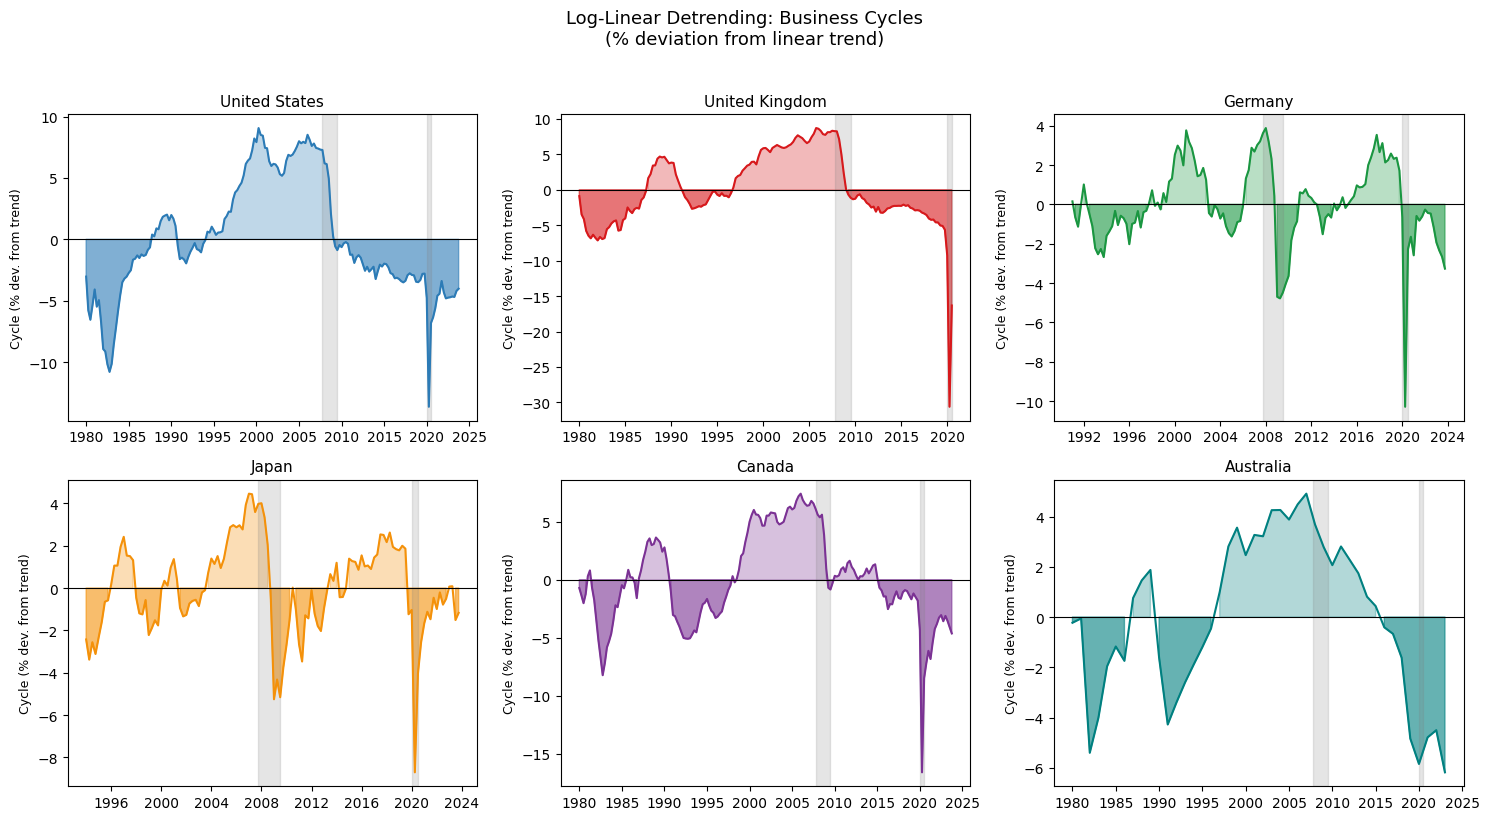

In [5]:
# ──────────────────────────────────────────────
# Log-linear and log-quadratic detrending
# ──────────────────────────────────────────────
def linear_detrend(series):
    """OLS regression on linear time trend; return cycle."""
    T   = len(series)
    t   = np.arange(T)
    X   = sm.add_constant(t)
    res = sm.OLS(series.values, X).fit()
    trend  = res.fittedvalues
    cycle  = series.values - trend
    return pd.Series(cycle, index=series.index), \
           pd.Series(trend, index=series.index)

def quadratic_detrend(series):
    """OLS regression on quadratic time trend; return cycle."""
    T   = len(series)
    t   = np.arange(T)
    X   = sm.add_constant(np.column_stack([t, t**2]))
    res = sm.OLS(series.values, X).fit()
    trend  = res.fittedvalues
    cycle  = series.values - trend
    return pd.Series(cycle, index=series.index), \
           pd.Series(trend, index=series.index)

# ──────────────────────────────────────────────
# Plot: trend fit and cycle for each country
# ──────────────────────────────────────────────
fig1, axes1 = plt.subplots(3, 2, figsize=(14, 12))
axes1 = axes1.flatten()

cycles_linear = {}
for idx, (country, series) in enumerate(gdp_data.items()):
    cycle_lin,  trend_lin  = linear_detrend(series)
    cycle_quad, trend_quad = quadratic_detrend(series)
    cycles_linear[country] = cycle_lin

    ax = axes1[idx]

    ax.plot(series.index, series.values,
            color=colors[country], lw=1.5, alpha=0.7,
            label="Log GDP")
    ax.plot(series.index, trend_lin.values,
            color="black", lw=1.5, ls="--",
            label="Linear trend")
    ax.plot(series.index, trend_quad.values,
            color="gray", lw=1.5, ls="-.",
            label="Quadratic trend")
    ax.fill_between(series.index,
                    trend_lin.values,
                    trend_lin.values + cycle_lin.values,
                    where=cycle_lin.values >= 0,
                    color="#d7191c", alpha=0.3,
                    label="Cycle > 0 (boom)")
    ax.fill_between(series.index,
                    trend_lin.values,
                    trend_lin.values + cycle_lin.values,
                    where=cycle_lin.values < 0,
                    color="#d7191c", alpha=0.6,
                    label="Cycle < 0 (recession)")
    for (start, end) in [("2007-10-01", "2009-07-01"),
                          ("2020-01-01", "2020-07-01")]:
        ax.axvspan(pd.to_datetime(start),
                   pd.to_datetime(end),
                   color="gray", alpha=0.15)
    ax.set_title(country, fontsize=11)
    ax.set_ylabel("Log Real GDP", fontsize=9)
    ax.legend(fontsize=7, loc="upper left")

fig1.suptitle("Log-Linear Detrending: Trend and Cycle\n"
              "(shaded area = deviation of GDP from linear trend)",
              fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────
# Second figure: log deviation from linear trend
# Mirrors the HP filter cycle plots exactly
# ──────────────────────────────────────────────
fig2, axes2 = plt.subplots(2, 3, figsize=(15, 8))
axes2 = axes2.flatten()

for idx, (country, series) in enumerate(gdp_data.items()):
    cycle = cycles_linear[country]
    ax    = axes2[idx]

    ax.plot(series.index, cycle.values * 100,
            color=colors[country], lw=1.5)
    ax.axhline(0, color="black", lw=0.8)
    ax.fill_between(series.index,
                    cycle.values * 100, 0,
                    where=cycle.values > 0,
                    color=colors[country], alpha=0.3)
    ax.fill_between(series.index,
                    cycle.values * 100, 0,
                    where=cycle.values < 0,
                    color=colors[country], alpha=0.6)
    for (start, end) in [("2007-10-01", "2009-07-01"),
                          ("2020-01-01", "2020-07-01")]:
        ax.axvspan(pd.to_datetime(start),
                   pd.to_datetime(end),
                   color="gray", alpha=0.2)
    ax.set_title(country, fontsize=11)
    ax.set_ylabel("Cycle (% dev. from trend)", fontsize=9)

fig2.suptitle("Log-Linear Detrending: Business Cycles\n"
              "(% deviation from linear trend)",
              fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Method 2: The Hodrick-Prescott Filter

### Theory

Hodrick and Prescott (1981) propose choosing the trend $\tau_t$ by solving a penalized least squares problem:

$$\min_{\{\tau_t\}} \sum_{t=1}^{T}(y_t - \tau_t)^2 + 
\lambda\sum_{t=2}^{T-1}[(\tau_{t+1} - \tau_t) - (\tau_t - \tau_{t-1})]^2$$

The first term penalizes deviations of the trend from the data — if $\lambda = 0$, the trend equals the data exactly and the cycle is zero. The second term penalizes changes in the trend's growth rate — if $\lambda \to \infty$, the trend growth rate is forced to be constant and the HP filter converges to a log-linear trend. The parameter $\lambda$ therefore governs the smoothness of the trend: larger $\lambda$ produces a smoother trend and a more volatile cycle.

The first-order conditions $\partial f/\partial \tau_t = 0$ for all $t$ reduce to a linear system $A\tau = y$, where $A$ is an $T \times T$ band matrix determined by $\lambda$. The solution is:

$$\hat{\tau} = (I + \lambda K'K)^{-1}y$$

where $K$ is the second-difference matrix. This can be solved efficiently using sparse linear algebra, and is implemented in `statsmodels`.

**Choice of $\lambda$.** Convention sets $\lambda = 1600$ for quarterly data, $\lambda = 100$ for annual data, and $\lambda = 14400$ for monthly data. These values are calibrated so that the HP filter approximately isolates fluctuations with periodicities between 6 and 32 quarters — the conventional definition of the business cycle frequency band. However, the choice of $\lambda$ is contested, and we illustrate the sensitivity of the filter to this choice below.

**Known limitations.** The HP filter has been criticized on several grounds, most systematically by Hamilton (2017):

- It produces spurious dynamic relationships in the filtered series that have  no basis in the underlying data-generating process.
- The filter performs poorly at the endpoints of the sample: the trend estimate near the beginning and end of the series is unreliable because it has fewer observations on one side to anchor it.
- The conventional $\lambda = 1600$ is far from the value that would be optimal under a formal statistical criterion.

Despite these criticisms, the HP filter remains the most widely used detrending method in macroeconomics and is the benchmark against which most business cycle models are evaluated.

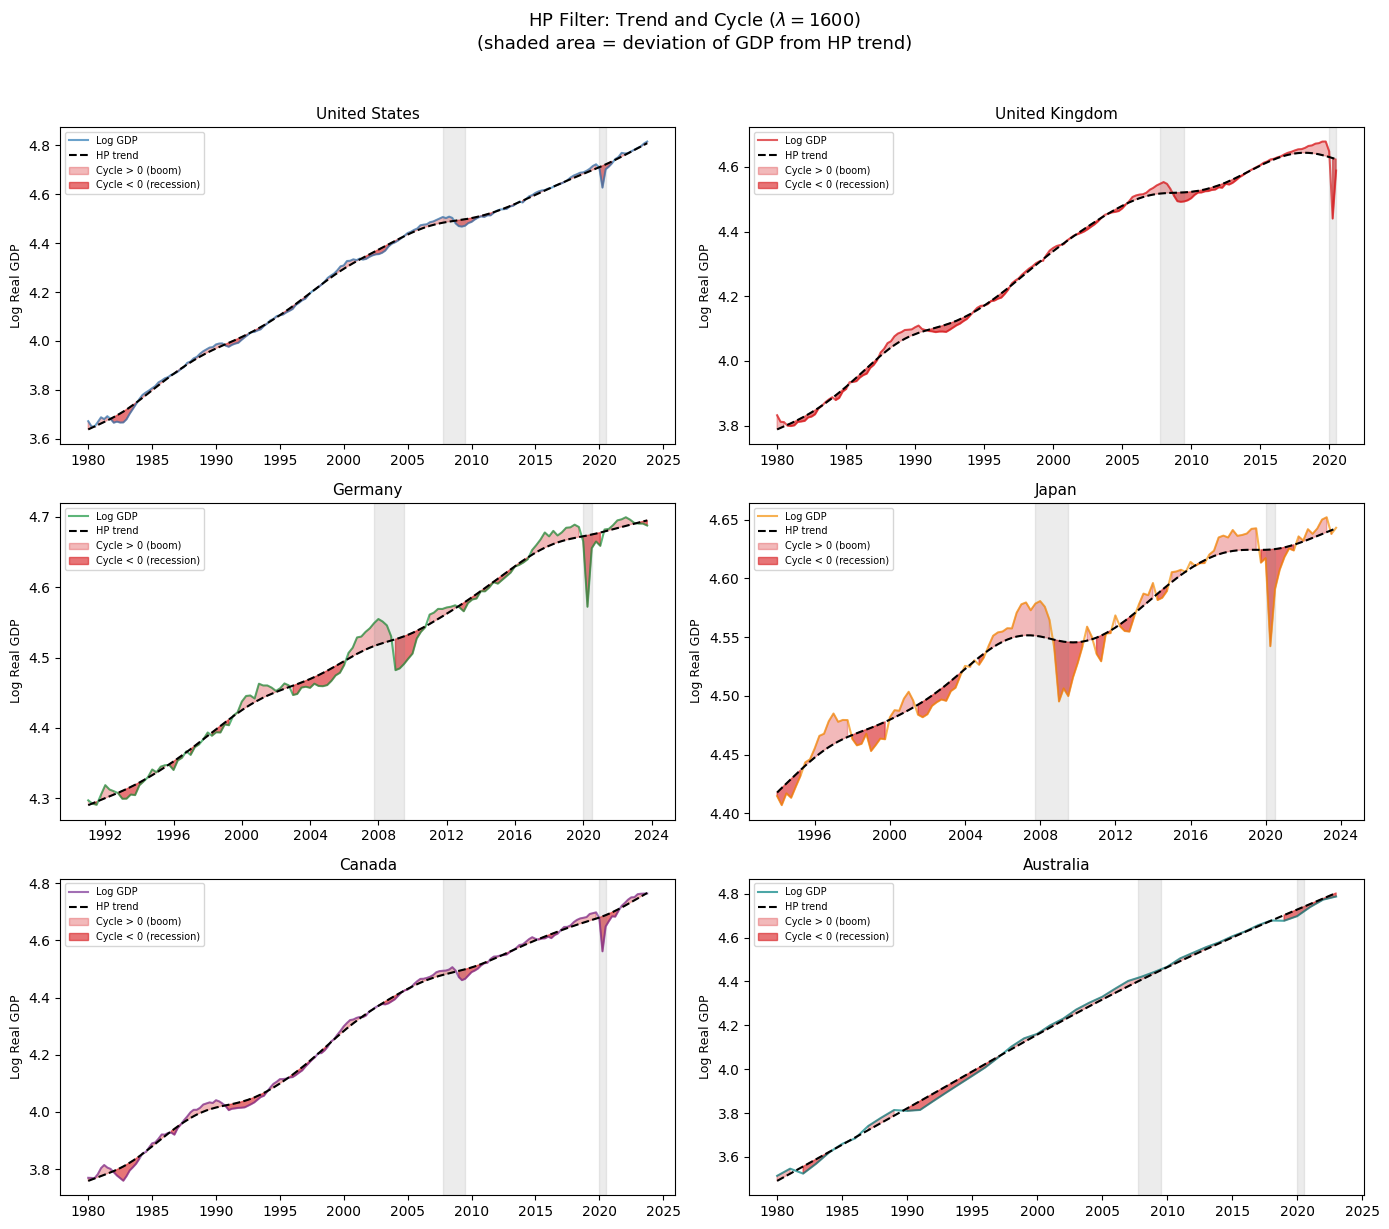

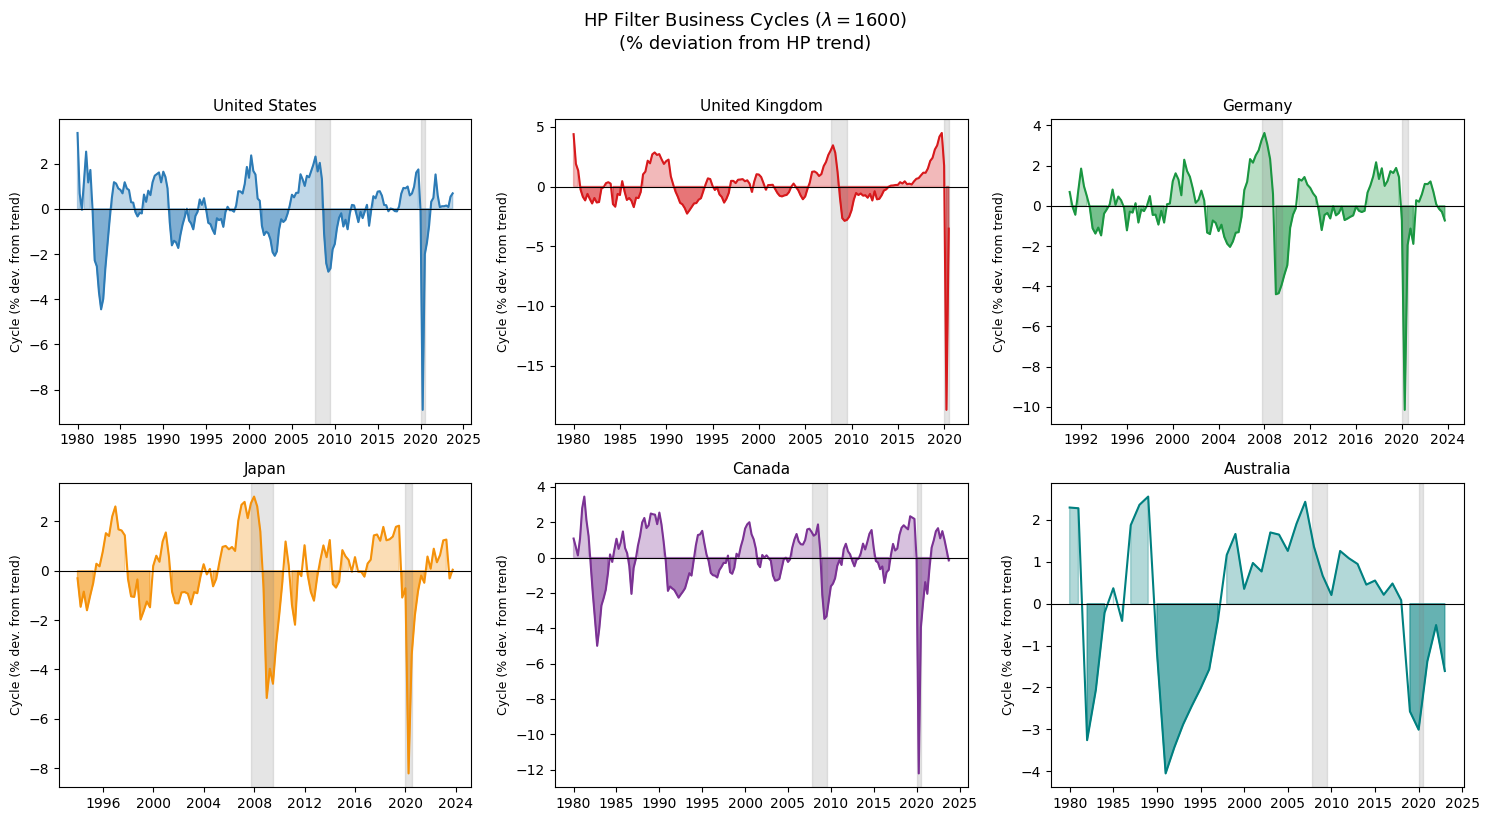

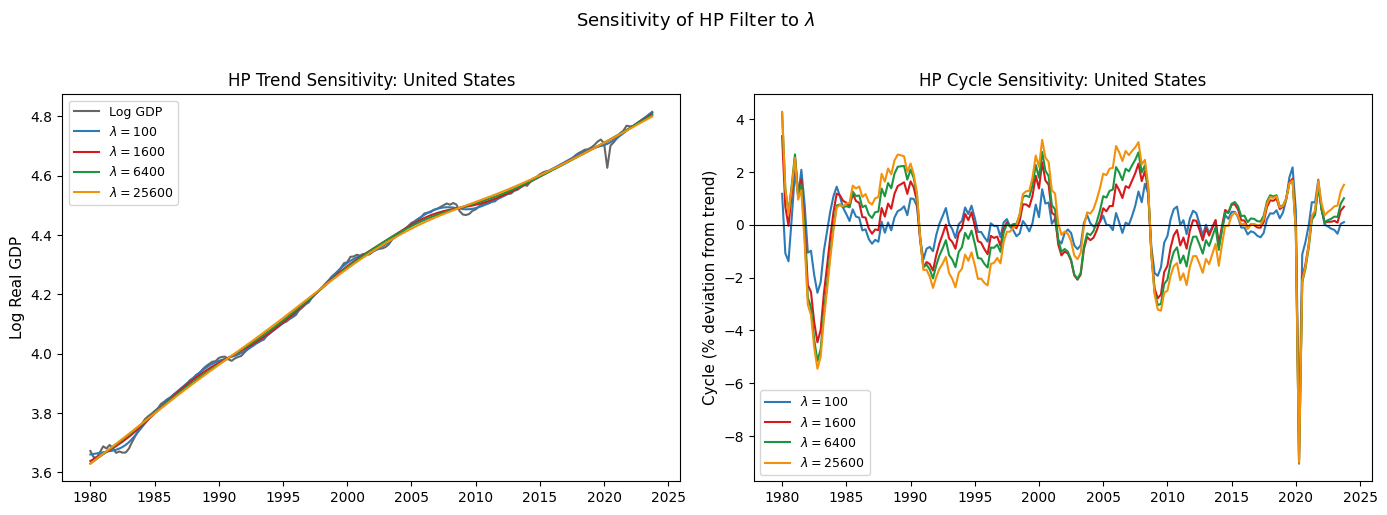

In [6]:
# ──────────────────────────────────────────────
# HP filter
# ──────────────────────────────────────────────
def hp_filter(series, lam=1600):
    cycle, trend = sm.tsa.filters.hpfilter(series.values, lam)
    return (pd.Series(cycle, index=series.index),
            pd.Series(trend, index=series.index))

cycles_hp = {}
for country, series in gdp_data.items():
    cycle, _ = hp_filter(series, lam=1600)
    cycles_hp[country] = cycle

# ──────────────────────────────────────────────
# Figure 1: Trend fit and cycle shading
# (mirrors log-linear figure 1)
# ──────────────────────────────────────────────
fig1, axes1 = plt.subplots(3, 2, figsize=(14, 12))
axes1 = axes1.flatten()

for idx, (country, series) in enumerate(gdp_data.items()):
    cycle, trend = hp_filter(series, lam=1600)

    ax = axes1[idx]
    ax.plot(series.index, series.values,
            color=colors[country], lw=1.5, alpha=0.7,
            label="Log GDP")
    ax.plot(series.index, trend.values,
            color="black", lw=1.5, ls="--",
            label="HP trend")
    ax.fill_between(series.index,
                    trend.values,
                    trend.values + cycle.values,
                    where=cycle.values >= 0,
                    color="#d7191c", alpha=0.3,
                    label="Cycle > 0 (boom)")
    ax.fill_between(series.index,
                    trend.values,
                    trend.values + cycle.values,
                    where=cycle.values < 0,
                    color="#d7191c", alpha=0.6,
                    label="Cycle < 0 (recession)")
    for (start, end) in [("2007-10-01", "2009-07-01"),
                          ("2020-01-01", "2020-07-01")]:
        ax.axvspan(pd.to_datetime(start),
                   pd.to_datetime(end),
                   color="gray", alpha=0.15)
    ax.set_title(country, fontsize=11)
    ax.set_ylabel("Log Real GDP", fontsize=9)
    ax.legend(fontsize=7, loc="upper left")

fig1.suptitle(r"HP Filter: Trend and Cycle ($\lambda = 1600$)"
              "\n(shaded area = deviation of GDP from HP trend)",
              fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────
# Figure 2: Log deviation from HP trend
# (mirrors log-linear figure 2)
# ──────────────────────────────────────────────
fig2, axes2 = plt.subplots(2, 3, figsize=(15, 8))
axes2 = axes2.flatten()

for idx, (country, series) in enumerate(gdp_data.items()):
    cycle = cycles_hp[country]
    ax    = axes2[idx]

    ax.plot(series.index, cycle.values * 100,
            color=colors[country], lw=1.5)
    ax.axhline(0, color="black", lw=0.8)
    ax.fill_between(series.index,
                    cycle.values * 100, 0,
                    where=cycle.values > 0,
                    color=colors[country], alpha=0.3)
    ax.fill_between(series.index,
                    cycle.values * 100, 0,
                    where=cycle.values < 0,
                    color=colors[country], alpha=0.6)
    for (start, end) in [("2007-10-01", "2009-07-01"),
                          ("2020-01-01", "2020-07-01")]:
        ax.axvspan(pd.to_datetime(start),
                   pd.to_datetime(end),
                   color="gray", alpha=0.2)
    ax.set_title(country, fontsize=11)
    ax.set_ylabel("Cycle (% dev. from trend)", fontsize=9)

fig2.suptitle(r"HP Filter Business Cycles ($\lambda = 1600$)"
              "\n(% deviation from HP trend)",
              fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────
# Figure 3: Sensitivity to lambda
# (unique to HP filter)
# ──────────────────────────────────────────────
country_demo = "United States"
series_demo  = gdp_data[country_demo]
lambda_vals  = [100, 1600, 6400, 25600]
lam_colors   = ["#2c7bb6", "#d7191c", "#1a9641", "#f4910a"]
lam_labels   = [r"$\lambda=100$", r"$\lambda=1600$",
                r"$\lambda=6400$", r"$\lambda=25600$"]

fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))

ax = axes3[0]
ax.plot(series_demo.index, series_demo.values,
        color="black", lw=1.5, alpha=0.6, label="Log GDP")
for lv, color, label in zip(lambda_vals, lam_colors, lam_labels):
    _, trend = hp_filter(series_demo, lam=lv)
    ax.plot(series_demo.index, trend.values,
            color=color, lw=1.5, label=label)
ax.set_title(f"HP Trend Sensitivity: {country_demo}",
             fontsize=12)
ax.set_ylabel("Log Real GDP", fontsize=11)
ax.legend(fontsize=9)

ax = axes3[1]
for lv, color, label in zip(lambda_vals, lam_colors, lam_labels):
    cycle, _ = hp_filter(series_demo, lam=lv)
    ax.plot(series_demo.index, cycle.values * 100,
            color=color, lw=1.5, label=label)
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"HP Cycle Sensitivity: {country_demo}",
             fontsize=12)
ax.set_ylabel("Cycle (% deviation from trend)", fontsize=11)
ax.legend(fontsize=9)

fig3.suptitle(r"Sensitivity of HP Filter to $\lambda$",
              fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The top figure shows the HP-filtered business cycle for all six countries. Positive values (light shading) indicate booms — output above trend; negative values (dark shading) indicate recessions — output below trend. The global financial crisis (2007–2009) and COVID-19 recession (2020) are clearly visible as troughs across all countries, though their depth and duration vary. The bottom figure illustrates the sensitivity of the HP filter to $\lambda$: a small $\lambda$ produces a trend that closely tracks the data, leaving little cyclical variation, while a large $\lambda$ produces a smooth trend close to the log-linear trend, with a more volatile cycle.

## Method 3: The Hamilton Filter

### Theory

Hamilton (2017) proposes an alternative to the HP filter that avoids its known shortcomings. The key insight is to define the cyclical component as the **unpredictable component** of the series at a horizon $h$:

$$y_{t+h} = \alpha + \beta_1 y_t + \beta_2 y_{t-1} + 
\beta_3 y_{t-2} + \beta_4 y_{t-3} + \varepsilon_{t+h}$$

The cycle at time $t+h$ is the OLS residual $\hat{\varepsilon}_{t+h}$: the difference between the realized value and the value predicted by the most recent four lags. Hamilton recommends $h = 8$ quarters (two years) and $p = 4$ lags for quarterly data — both are multiples of the seasonal frequency, which helps avoid spurious seasonal contamination of the cycle.

**Why $h = 8$?** Hamilton argues that a two-year forecast horizon corresponds naturally to the business cycle concept: we want to identify deviations from what the economy was expected to achieve two years ago, based on information available at that time. This definition is robust to a wide class of data-generating processes, including unit root processes, whereas the HP filter requires stationarity assumptions that may not hold.

**Advantages over HP.** The Hamilton filter does not produce spurious autocorrelation in the residuals, performs consistently throughout the sample (including at the endpoints), and has a clear statistical interpretation as a forecast error. Its main disadvantage is that it uses $h + p = 12$ observations to start the regression, losing observations at the beginning of the sample, and its cycle component may include frequencies outside the conventional business cycle band.

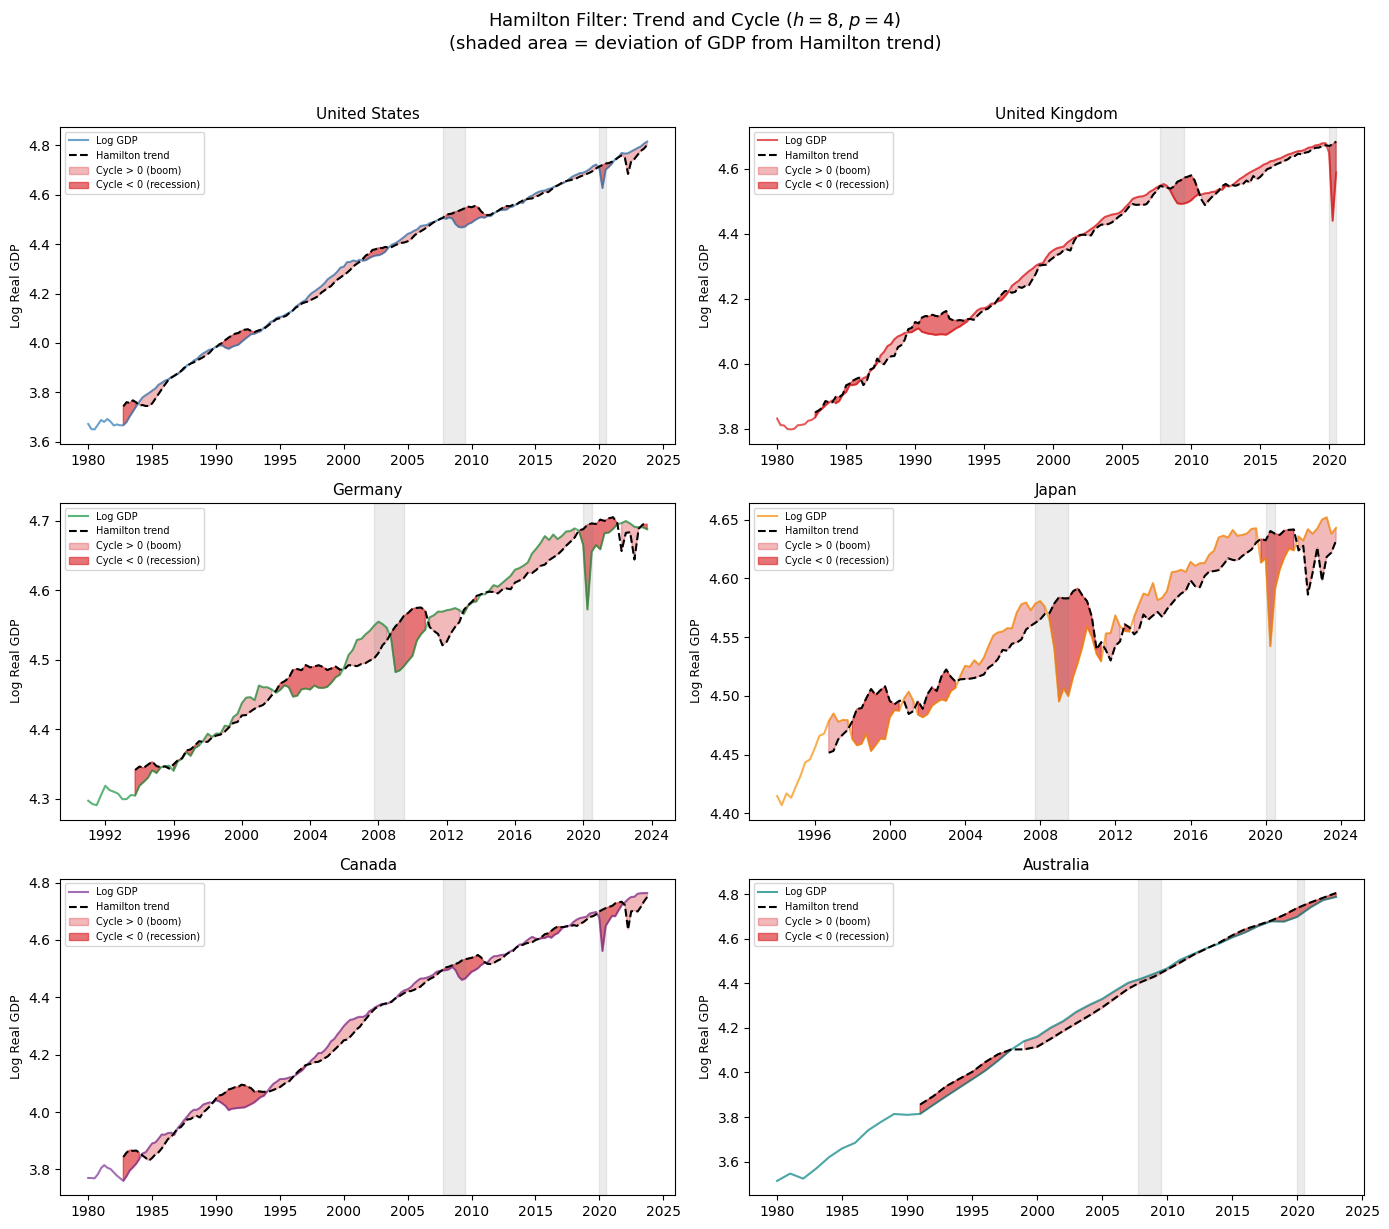

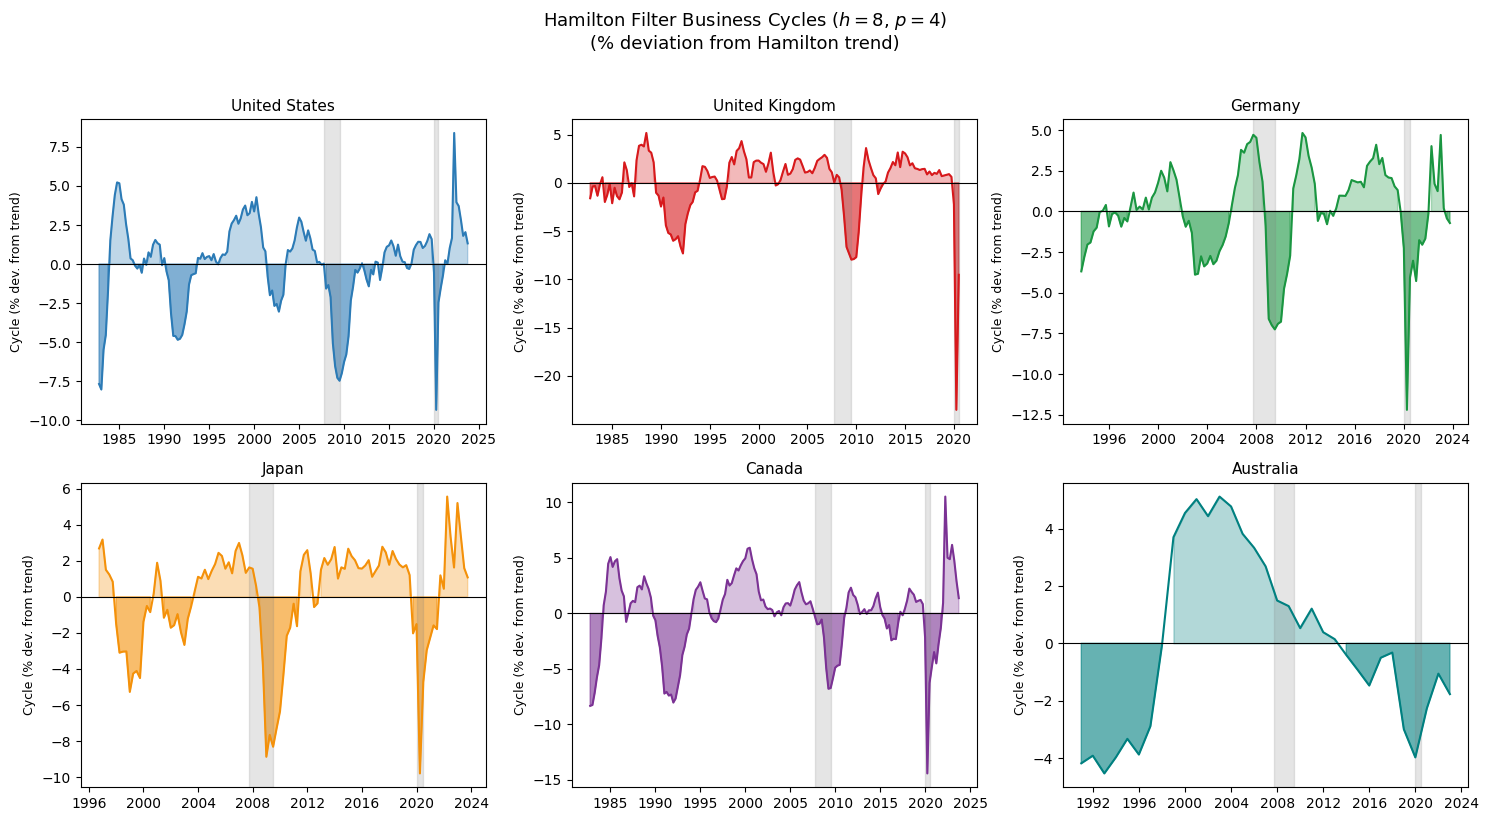

In [8]:
# ──────────────────────────────────────────────
# Hamilton filter
# ──────────────────────────────────────────────
def hamilton_filter(series, h=8, p=4):
    y      = series.values
    T      = len(y)
    cycles = np.full(T, np.nan)

    n_obs = T - h - p + 1
    if n_obs < 10:
        return pd.Series(np.nan, index=series.index)

    Y = np.zeros(n_obs)
    X = np.zeros((n_obs, p + 1))

    for i in range(n_obs):
        t = i + p - 1
        Y[i]    = y[t + h]
        X[i, 0] = 1.0
        for j in range(p):
            X[i, j+1] = y[t - j]

    res   = sm.OLS(Y, X).fit()
    resid = res.resid

    for i, r in enumerate(resid):
        t_plus_h = i + p - 1 + h
        cycles[t_plus_h] = r

    return pd.Series(cycles, index=series.index)

def hamilton_trend(series, h=8, p=4):
    """
    Hamilton trend = series - cycle.
    Defined only where the cycle is non-NaN.
    """
    cycle = hamilton_filter(series, h=h, p=p)
    trend = series - cycle
    return cycle, trend

# ──────────────────────────────────────────────
# Compute cycles and trends for all countries
# ──────────────────────────────────────────────
cycles_hamilton = {}
trends_hamilton = {}
for country, series in gdp_data.items():
    cycle, trend = hamilton_trend(series)
    cycles_hamilton[country] = cycle
    trends_hamilton[country] = trend

# ──────────────────────────────────────────────
# Figure 1: Trend fit and cycle shading
# (mirrors log-linear and HP figure 1)
# ──────────────────────────────────────────────
fig1, axes1 = plt.subplots(3, 2, figsize=(14, 12))
axes1 = axes1.flatten()

for idx, (country, series) in enumerate(gdp_data.items()):
    cycle = cycles_hamilton[country]
    trend = trends_hamilton[country]

    # Only plot where trend is defined (non-NaN)
    valid = trend.dropna().index

    ax = axes1[idx]
    ax.plot(series.index, series.values,
            color=colors[country], lw=1.5, alpha=0.7,
            label="Log GDP")
    ax.plot(valid, trend.loc[valid].values,
            color="black", lw=1.5, ls="--",
            label="Hamilton trend")
    ax.fill_between(valid,
                    trend.loc[valid].values,
                    trend.loc[valid].values
                    + cycle.loc[valid].values,
                    where=cycle.loc[valid].values >= 0,
                    color="#d7191c", alpha=0.3,
                    label="Cycle > 0 (boom)")
    ax.fill_between(valid,
                    trend.loc[valid].values,
                    trend.loc[valid].values
                    + cycle.loc[valid].values,
                    where=cycle.loc[valid].values < 0,
                    color="#d7191c", alpha=0.6,
                    label="Cycle < 0 (recession)")
    for (start, end) in [("2007-10-01", "2009-07-01"),
                          ("2020-01-01", "2020-07-01")]:
        ax.axvspan(pd.to_datetime(start),
                   pd.to_datetime(end),
                   color="gray", alpha=0.15)
    ax.set_title(country, fontsize=11)
    ax.set_ylabel("Log Real GDP", fontsize=9)
    ax.legend(fontsize=7, loc="upper left")

fig1.suptitle("Hamilton Filter: Trend and Cycle ($h=8$, $p=4$)\n"
              "(shaded area = deviation of GDP from Hamilton trend)",
              fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────
# Figure 2: Log deviation from Hamilton trend
# (mirrors log-linear and HP figure 2)
# ──────────────────────────────────────────────
fig2, axes2 = plt.subplots(2, 3, figsize=(15, 8))
axes2 = axes2.flatten()

for idx, (country, series) in enumerate(gdp_data.items()):
    cycle = cycles_hamilton[country]
    ax    = axes2[idx]

    ax.plot(series.index, cycle.values * 100,
            color=colors[country], lw=1.5)
    ax.axhline(0, color="black", lw=0.8)
    ax.fill_between(series.index,
                    cycle.fillna(0).values * 100, 0,
                    where=cycle.fillna(0).values > 0,
                    color=colors[country], alpha=0.3)
    ax.fill_between(series.index,
                    cycle.fillna(0).values * 100, 0,
                    where=cycle.fillna(0).values < 0,
                    color=colors[country], alpha=0.6)
    for (start, end) in [("2007-10-01", "2009-07-01"),
                          ("2020-01-01", "2020-07-01")]:
        ax.axvspan(pd.to_datetime(start),
                   pd.to_datetime(end),
                   color="gray", alpha=0.2)
    ax.set_title(country, fontsize=11)
    ax.set_ylabel("Cycle (% dev. from trend)", fontsize=9)

fig2.suptitle("Hamilton Filter Business Cycles ($h=8$, $p=4$)\n"
              "(% deviation from Hamilton trend)",
              fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Method 4: Band-Pass Filters

### Theory

Band-pass filters take a spectral perspective on the trend-cycle decomposition. Any time series can be represented as a sum of sinusoidal components with different frequencies. The business cycle corresponds to fluctuations with periodicities between 6 and 32 quarters — following Burns and Mitchell's empirical work on US business cycles — while lower-frequency components correspond to the trend and higher-frequency components correspond to irregular noise. A band-pass filter removes all components outside the target frequency band, retaining only the business cycle frequencies.

**The Baxter-King (BK) filter** implements this idea using a symmetric moving average:

$$\hat{y}_t = \sum_{k=-K}^{K} a_k y_{t-k}$$

where the weights $a_k$ are chosen to approximate the ideal band-pass filter in the frequency domain. The constraint $\sum_k a_k = 0$ ensures that any linear trend in the series is eliminated. Following Baxter and King's recommendations, we use $P_L = 6$, $P_H = 32$, and $K = 12$ for quarterly data. The symmetric moving average means the filter loses $K = 12$ observations at each end of the sample.

**The Christiano-Fitzgerald (CF) filter** generalizes the BK filter by using an asymmetric, time-varying moving average that adapts to the full length of the available data. This avoids the endpoint observation loss of the BK filter and generally provides a closer approximation to the ideal band-pass filter, at the cost of somewhat greater complexity.

Both filters are implemented in `statsmodels`. We present them together and focus on interpreting the output rather than the technical details of the weight construction.

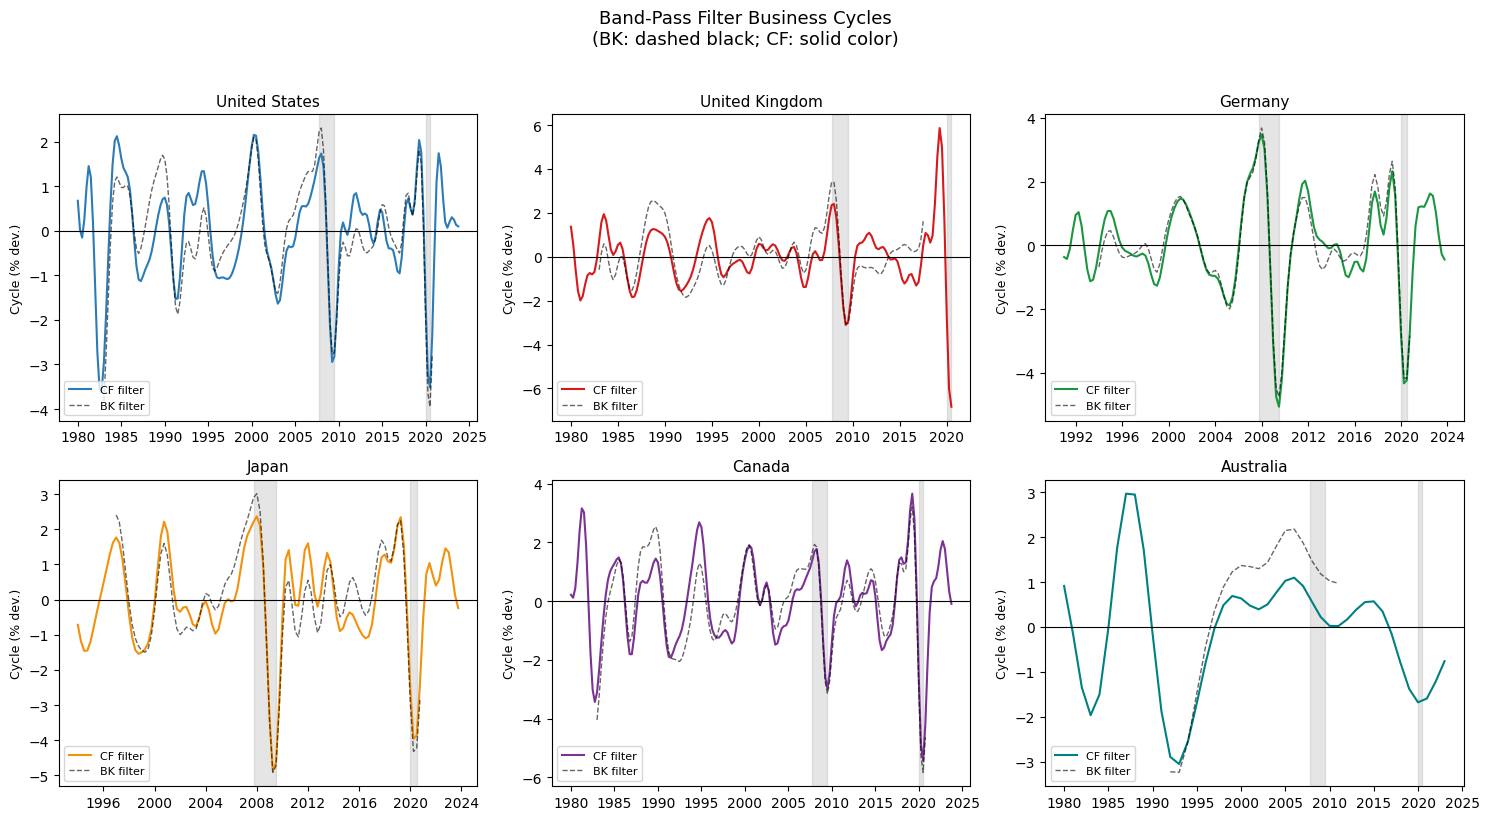

In [9]:
# ──────────────────────────────────────────────
# Baxter-King and Christiano-Fitzgerald filters
# ──────────────────────────────────────────────
def bk_filter(series, low=6, high=32, K=12):
    try:
        cycle = sm.tsa.filters.bkfilter(
            series.values, low=low, high=high, K=K)
        # BK loses K obs at each end
        idx = series.index[K:-K]
        return pd.Series(cycle, index=idx)
    except Exception:
        return pd.Series(np.nan, index=series.index)

def cf_filter(series, low=6, high=32):
    try:
        cycle, trend = sm.tsa.filters.cffilter(
            series.values, low=low, high=high)
        return pd.Series(cycle, index=series.index)
    except Exception:
        return pd.Series(np.nan, index=series.index)

# ──────────────────────────────────────────────
# Plot BK and CF cycles for all countries
# ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

cycles_bk = {}
cycles_cf = {}
for idx, (country, series) in enumerate(gdp_data.items()):
    cycle_bk = bk_filter(series)
    cycle_cf = cf_filter(series)
    cycles_bk[country] = cycle_bk
    cycles_cf[country] = cycle_cf

    ax = axes[idx]
    ax.plot(cycle_cf.index, cycle_cf.values * 100,
            color=colors[country], lw=1.5,
            label="CF filter")
    ax.plot(cycle_bk.index, cycle_bk.values * 100,
            color="black", lw=1, ls="--", alpha=0.6,
            label="BK filter")
    ax.axhline(0, color="black", lw=0.8)
    for (start, end) in [("2007-10-01", "2009-07-01"),
                          ("2020-01-01", "2020-07-01")]:
        ax.axvspan(pd.to_datetime(start),
                   pd.to_datetime(end),
                   color="gray", alpha=0.2)
    ax.set_title(country, fontsize=11)
    ax.set_ylabel("Cycle (% dev.)", fontsize=9)
    ax.legend(fontsize=8, loc="lower left")

fig.suptitle("Band-Pass Filter Business Cycles\n"
             "(BK: dashed black; CF: solid color)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Comparing the Four Methods

Having computed cycles using all four methods, we now compare them directly. A good filter should: (i) identify the same broad cyclical turning points across methods; (ii) produce cycles that are uncorrelated with the raw series at long horizons (no trend contamination); and (iii) yield cycles that are synchronized across countries during global recessions. We assess each criterion in turn.

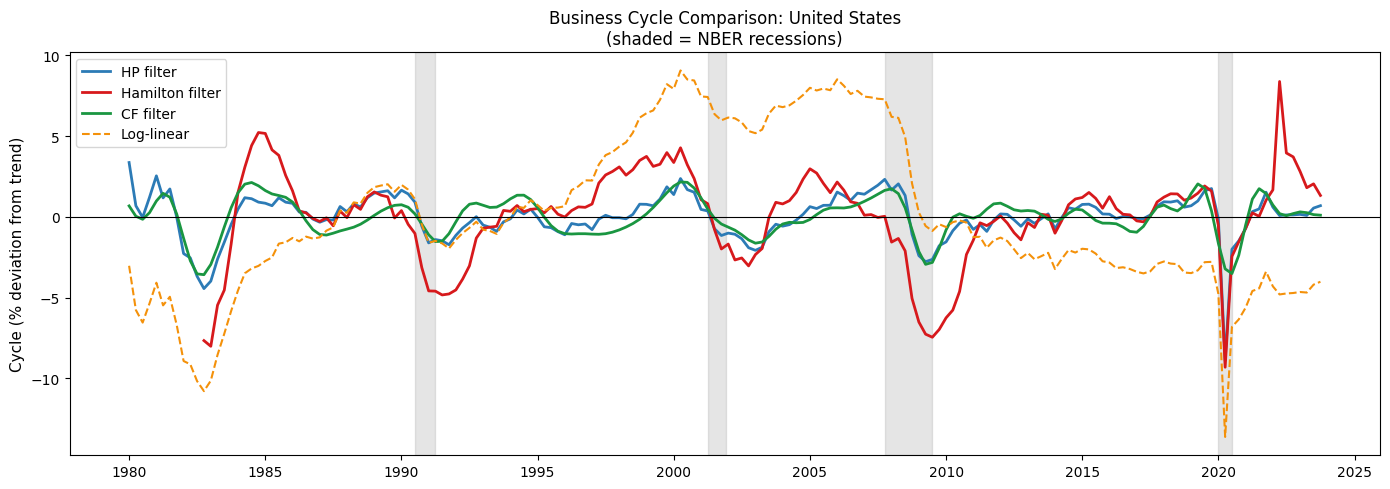

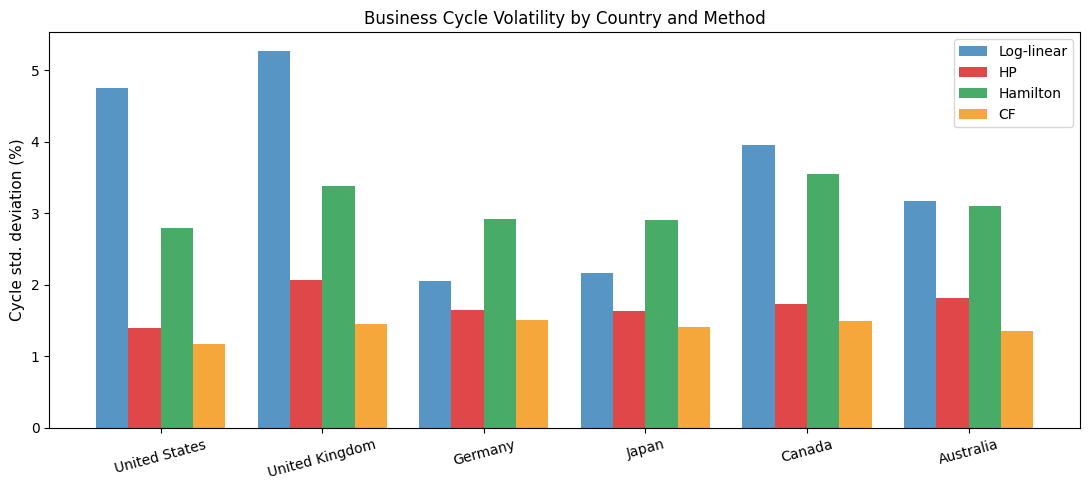

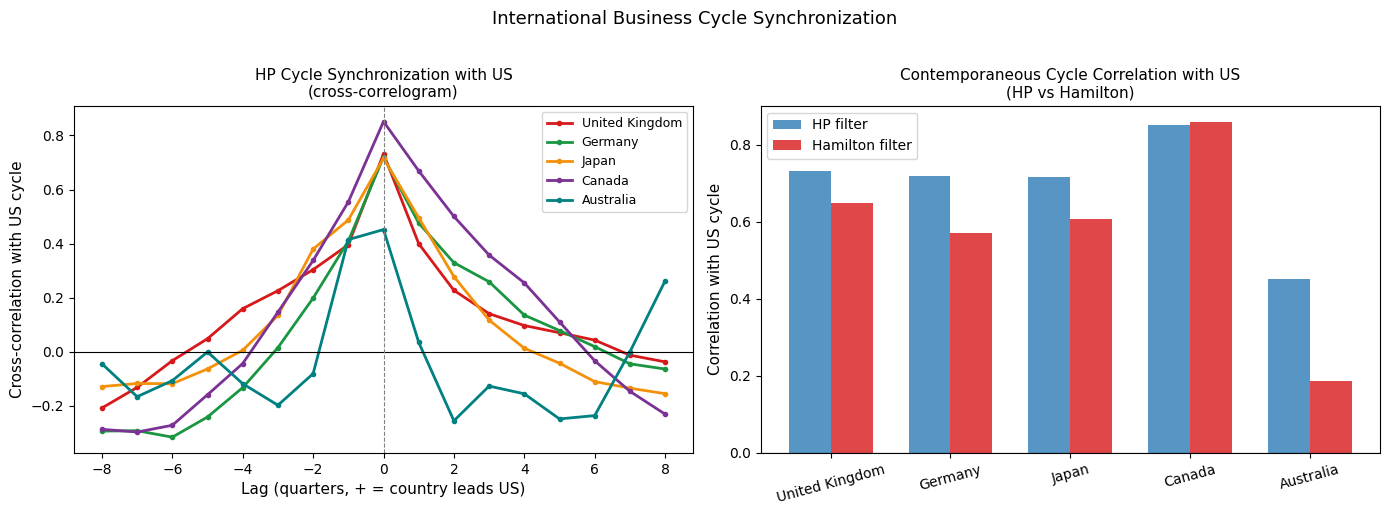

In [10]:
# ──────────────────────────────────────────────
# Comparison 1: Overlay all four cycles
# for United States
# ──────────────────────────────────────────────
country_cmp = "United States"
series_cmp  = gdp_data[country_cmp]

c_lin  = cycles_linear[country_cmp]
c_hp   = cycles_hp[country_cmp]
c_ham  = cycles_hamilton[country_cmp]
c_cf   = cycles_cf[country_cmp]
c_bk   = cycles_bk[country_cmp]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(series_cmp.index, c_hp.values*100,
        color="#2c7bb6", lw=2, label="HP filter")
ax.plot(series_cmp.index, c_ham.values*100,
        color="#d7191c", lw=2, label="Hamilton filter")
ax.plot(series_cmp.index, c_cf.values*100,
        color="#1a9641", lw=2, label="CF filter")
ax.plot(series_cmp.index, c_lin.values*100,
        color="#f4910a", lw=1.5, ls="--",
        label="Log-linear")
ax.axhline(0, color="black", lw=0.8)

for (start, end) in [("1990-07-01", "1991-04-01"),
                      ("2001-04-01", "2001-12-01"),
                      ("2007-10-01", "2009-07-01"),
                      ("2020-01-01", "2020-07-01")]:
    ax.axvspan(pd.to_datetime(start),
               pd.to_datetime(end),
               color="gray", alpha=0.2)

ax.set_ylabel("Cycle (% deviation from trend)", fontsize=11)
ax.set_title(f"Business Cycle Comparison: {country_cmp}\n"
             "(shaded = NBER recessions)",
             fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────
# Comparison 2: Cycle volatility across countries
# and methods
# ──────────────────────────────────────────────
methods = {
    "Log-linear": cycles_linear,
    "HP"        : cycles_hp,
    "Hamilton"  : cycles_hamilton,
    "CF"        : cycles_cf,
}

countries = list(gdp_data.keys())
n_methods = len(methods)
n_countries = len(countries)

vol_matrix = np.zeros((n_countries, n_methods))
for j, (mname, cyc_dict) in enumerate(methods.items()):
    for i, country in enumerate(countries):
        c = cyc_dict.get(country)
        if c is not None:
            c_clean = c.dropna()
            vol_matrix[i, j] = c_clean.std() * 100

fig, ax = plt.subplots(figsize=(11, 5))
x      = np.arange(n_countries)
width  = 0.2
mcols  = ["#2c7bb6", "#d7191c", "#1a9641", "#f4910a"]
for j, (mname, color) in enumerate(zip(methods.keys(), mcols)):
    ax.bar(x + j*width, vol_matrix[:, j],
           width, label=mname, color=color, alpha=0.8)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(countries, fontsize=10, rotation=15)
ax.set_ylabel("Cycle std. deviation (%)", fontsize=11)
ax.set_title("Business Cycle Volatility by Country and Method",
             fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────
# Comparison 3: International synchronization
# Pairwise correlation of HP cycles with US
# ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cross-correlations with US HP cycle
us_hp = cycles_hp["United States"].dropna()
other_countries = [c for c in countries if c != "United States"]

ax = axes[0]
for country in other_countries:
    c_hp_other = cycles_hp[country].dropna()
    # Align on common dates
    common = us_hp.index.intersection(c_hp_other.index)
    if len(common) < 20:
        continue
    lags  = range(-8, 9)
    corrs = []
    for lag in lags:
        if lag >= 0:
            x1 = us_hp.loc[common].values[:len(common)-lag]
            x2 = c_hp_other.loc[common].values[lag:]
        else:
            x1 = us_hp.loc[common].values[-lag:]
            x2 = c_hp_other.loc[common].values[:len(common)+lag]
        if len(x1) > 10:
            corrs.append(np.corrcoef(x1, x2)[0, 1])
        else:
            corrs.append(np.nan)
    ax.plot(list(lags), corrs,
            color=colors[country], lw=2, marker="o",
            markersize=3, label=country)

ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("Lag (quarters, + = country leads US)",
              fontsize=11)
ax.set_ylabel("Cross-correlation with US cycle", fontsize=11)
ax.set_title("HP Cycle Synchronization with US\n"
             "(cross-correlogram)", fontsize=11)
ax.legend(fontsize=9)

# Contemporaneous correlation: HP vs Hamilton
ax = axes[1]
corr_hp  = []
corr_ham = []
for country in other_countries:
    # HP
    c1 = cycles_hp.get(country)
    c2 = cycles_hp["United States"]
    if c1 is not None and c2 is not None:
        common = c1.dropna().index.intersection(
                 c2.dropna().index)
        if len(common) > 20:
            r, _ = pearsonr(c1.loc[common], c2.loc[common])
            corr_hp.append(r)
        else:
            corr_hp.append(np.nan)
    # Hamilton
    c1h = cycles_hamilton.get(country)
    c2h = cycles_hamilton["United States"]
    if c1h is not None and c2h is not None:
        common = c1h.dropna().index.intersection(
                 c2h.dropna().index)
        if len(common) > 20:
            r, _ = pearsonr(c1h.loc[common], c2h.loc[common])
            corr_ham.append(r)
        else:
            corr_ham.append(np.nan)

x2     = np.arange(len(other_countries))
width2 = 0.35
ax.bar(x2 - width2/2, corr_hp,  width2,
       color="#2c7bb6", alpha=0.8, label="HP filter")
ax.bar(x2 + width2/2, corr_ham, width2,
       color="#d7191c", alpha=0.8, label="Hamilton filter")
ax.set_xticks(x2)
ax.set_xticklabels(other_countries, fontsize=10, rotation=15)
ax.set_ylabel("Correlation with US cycle", fontsize=11)
ax.set_title("Contemporaneous Cycle Correlation with US\n"
             "(HP vs Hamilton)", fontsize=11)
ax.legend(fontsize=10)
ax.axhline(0, color="black", lw=0.8)

fig.suptitle("International Business Cycle Synchronization",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Summary of Filter Properties

The comparison across methods reveals several consistent patterns and some important differences:

**Agreement on major turning points.** All four methods identify the same broad cyclical turning points — the early 1990s recession, the 2001 dot-com slowdown, the 2008–2009 global financial crisis, and the 2020 COVID recession. This agreement is reassuring: it suggests that the major features of the business cycle are genuine and not artifacts of the filtering method.

**Disagreement on cycle amplitude.** The methods differ substantially in their estimates of cycle volatility (as shown in the bar chart). The HP filter tends to produce a smoother trend and therefore larger cycles; the Hamilton filter, by conditioning on four quarters of lags, assigns more of the variance to the predictable component and produces a less volatile cycle. The log-linear filter produces the most volatile cycles because it fits the smoothest possible trend.

**Endpoint reliability.** The HP filter performs poorly near the end of the sample — the trend estimate for the most recent observations relies heavily on the filter's endpoint correction and is sensitive to data revisions. The Hamilton filter does not have this problem: the regression residuals are well-defined throughout the sample. This matters in real-time analysis, where the most recent observations are exactly the ones of policy interest.

**International synchronization.** The cross-correlogram confirms that business cycles are highly synchronized internationally, particularly around global events like the GFC and COVID. The UK, Canada, and Australia show the highest contemporaneous correlation with the US cycle; Japan shows a somewhat lower correlation, reflecting structural differences in its business cycle. Both the HP and Hamilton filters tell a broadly similar story about international synchronization, though the Hamilton filter tends to produce slightly lower correlations — consistent with it filtering out some of the common trend component that the HP filter leaves in the cycle.

## Conclusion

Extracting business cycles from macroeconomic data requires choosing among several imperfect methods, each of which imposes different implicit assumptions about the nature of trend and cycle. The main lessons from this notebook are:

- **Log-transform first**: variables that grow exponentially should be log-transformed before filtering to convert the exponential trend into a linear one.
- **The HP filter** is the standard benchmark and is appropriate for most applications. Its main weaknesses are endpoint unreliability and potential spurious dynamics in the filtered series.
- **The Hamilton filter** is a principled alternative that avoids the HP filter's statistical shortcomings. Its cycle has a clean interpretation as a forecast error at a two-year horizon.
- **Band-pass filters** (BK and CF) are useful when the goal is specifically to isolate fluctuations within the conventional business cycle frequency band. They are less flexible than the other methods but have the cleanest frequency-domain interpretation.
- **The choice of filter matters for magnitudes but not for qualitative conclusions**: major recessions and the broad pattern of international synchronization are robust across all methods.

In practice, the best approach is to apply multiple methods and check whether the conclusions of interest are robust to the choice of filter. A result that holds only under one specific filtering method should be treated with caution.